In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [21]:
df = pd.read_csv('BostonHousing.csv')

In [22]:
X = df.drop(columns=['medv'])
y = df['medv']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

In [25]:
models = {
    "Linear Regression": LinearRegression()
    
}

In [26]:
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    # Performance metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "RMSE ($1000s)": round(rmse, 3),
        "MAE ($1000s)": round(mae, 3),
        "R² Score": round(r2, 4)
    })

In [27]:
results_df = pd.DataFrame(results).sort_values(by="R² Score", ascending=False)
print("--- Model Evaluation Summary ---")
print(results_df.to_string(index=False))

--- Model Evaluation Summary ---
            Model  RMSE ($1000s)  MAE ($1000s)  R² Score
Linear Regression          4.945         3.211    0.6665


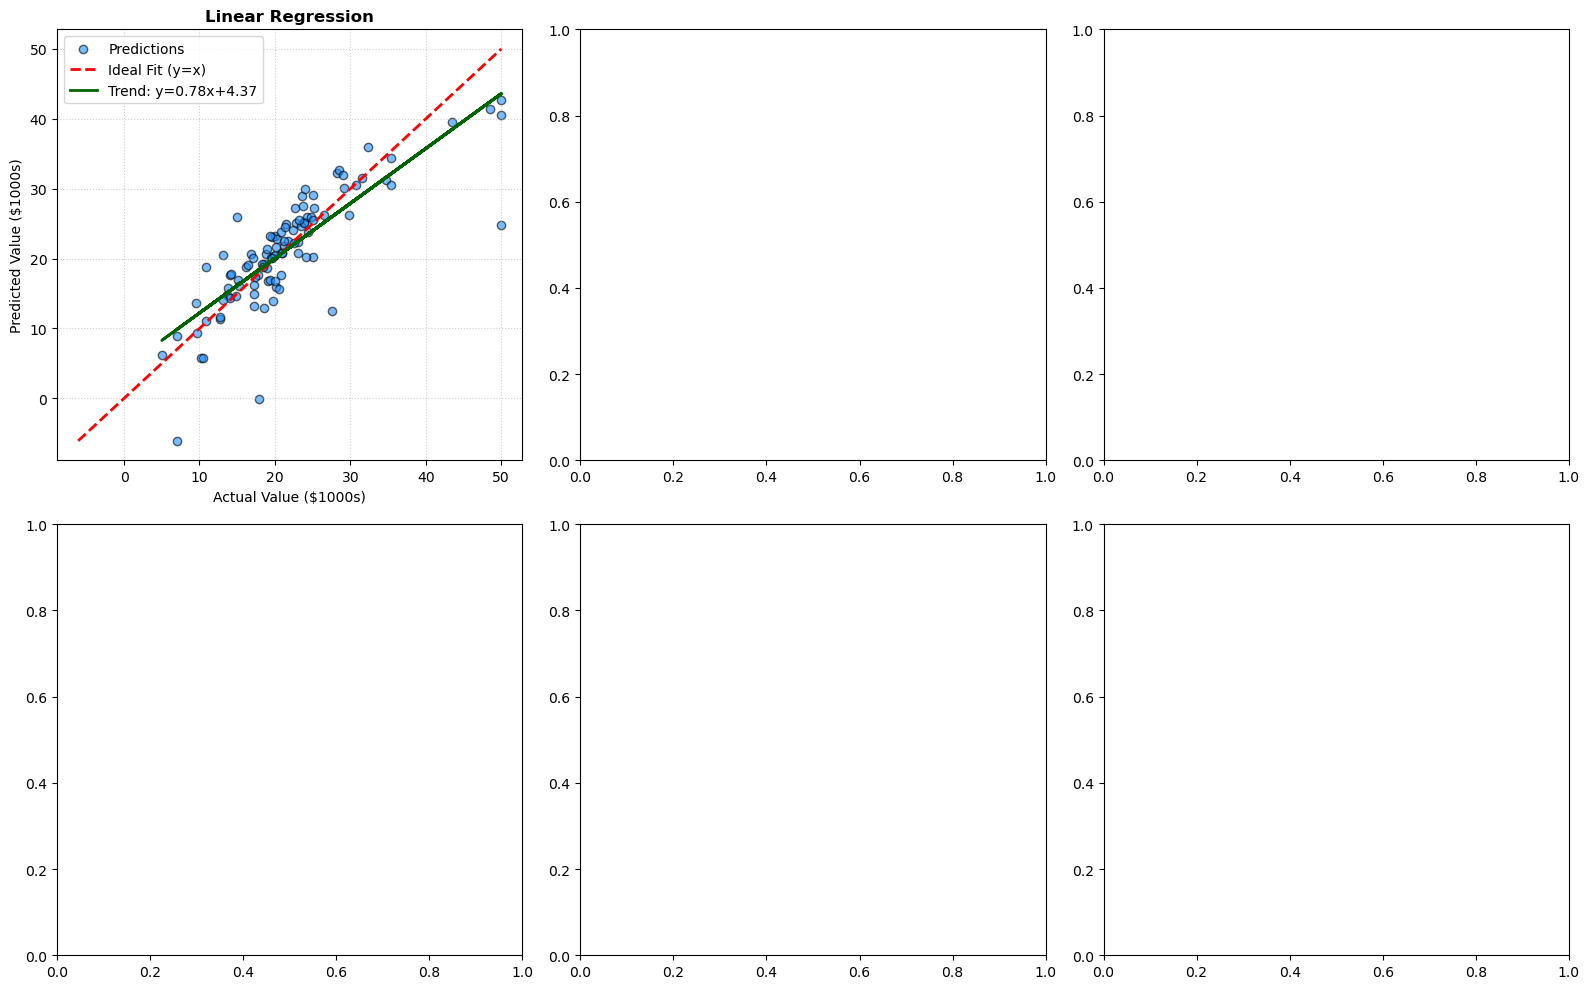

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    ax = axes[idx]
    ax.scatter(y_test, y_pred, alpha=0.6, color='dodgerblue', edgecolors='k', label='Predictions')
    min_val, max_val = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal Fit (y=x)')
    

    m, b = np.polyfit(y_test, y_pred, 1)
    ax.plot(y_test, m*y_test + b, color='darkgreen', lw=2, label=f'Trend: y={m:.2f}x+{b:.2f}')
    
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Actual Value ($1000s)')
    ax.set_ylabel('Predicted Value ($1000s)')
    ax.legend()
    ax.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()